<a href="https://colab.research.google.com/github/kuroMJ-rider/mission12/blob/main/mission12_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 미션12 문제 정의

1. **분석 배경 및 목표**

- 페르소나: 자전거 대여 시스템 운영 담당자 임무 수행함.

- 최종 목표: 대여 패턴 분석을 통한 자전거 배치 및 운영 전략 최적화임.

- 핵심 과제: 다양한 변수(날씨, 시간 등)를 활용하여 미래의 대여 수요를 정확히 예측하는 모델 개발함.

2. **해결 과제 (Objective)**

- 예측 대상: 특정 시간대의 총 자전거 대여 수(count)임.

- 분석 방향: 시간대별, 날씨별, 계절별 대여 패턴의 차이 규명함.

- 주말과 평일의 수요 차이 등 비즈니스 관점의 인사이트 도출함.

- 예측 모델을 기반으로 한 실질적인 운영 전략 제안함.

3. **평가 지표 (RMSLE)**

- 정의: 예측값과 실제값의 차이를 로그 변환하여 계산하는 지표임.

- 사용 이유: 수치적 차이보다 '몇 배 틀렸는지'에 대한 비율을 중요하게 평가함.

- 대여량이 적은 구간과 많은 구간의 오차를 고르게 반영함.

- 운영 관점에서 과도하게 자전거를 준비하거나 부족하게 준비하는 리스크 관리 목적임.

4. **데이터 및 제출물**

- train.csv: 학습용 데이터 (대여량 count 포함됨).

- test.csv: 테스트용 데이터 (수요 예측 대상임).

- 제출물 : 코랩 노트북(전처리, 모델링, 성능 평가 전 과정 포함함), 보고서(가설 설정, 분석 전개, 최종 인사이트 정리함)

# 분석 환경 설정

In [1]:
# 개발환경 세팅하기
# ▶ 한글 폰트 다운로드
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name() # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,386 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and direc

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 코랩에서 그래프가 바로 보이게 설정
%matplotlib inline
# Pandas 보기 옵션
pd.set_option('display.max_columns',100)

In [5]:
# 경로 지정
import os
path = "/content/drive/MyDrive/[2025] CodeIt/[Sprint]mission/mission12/data/"
os.chdir(path)

In [6]:
ls

test.csv  train.csv


# 원본 데이터 살피기

## 1. train 데이터

In [7]:
# train 데이터 크기 확인
train = pd.read_csv('train.csv')
print(f"Train Data Shape: {train.shape}")

Train Data Shape: (10886, 12)


In [8]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [10]:
train['datetime'] = pd.to_datetime(train['datetime'])

In [11]:
train.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [12]:
train.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


## train 좀더 살필 것들
workingday :  평균(0.68)이 중앙값(1)보다 작음. 중앙값과 최댓값이 동일(1) -> 업무일에 데이터가 1에 쏠려있음 -> 평일 출퇴근 예측
casual : 중앙값 17, 평균 36, 75% 49, 최대값 367 -> right skewed
registered : 중앙값 118, 평균 155, 75% 222, 최댓값 886 -> right skewed
count : 중앙값 145, 평균 191, 75% 284, 최댓값 977 -> right skewed

이용자는 casual과 registerd로 나뉘어져 있음
casual + resigered = count

## 2. test 데이터

In [13]:
# test 데이터 크기 확인
test = pd.read_csv('test.csv')
print(f"Test Data Shape: {test.shape}")

Test Data Shape: (6493, 9)


In [14]:
test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [15]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 456.7+ KB


In [16]:
test['datetime'] = pd.to_datetime(test['datetime'])

In [17]:
test.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0


In [18]:
test.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
count,6493,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000
mean,2012-01-13 09:27:47.765285632,2.493300,0.029108,0.685815,1.436778,20.620607,24.012865,64.125212,12.631157
min,2011-01-20 00:00:00,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,16.000000,0.000000
25%,2011-07-22 15:00:00,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,49.000000,7.001500
50%,2012-01-20 23:00:00,3.000000,0.000000,1.000000,1.000000,21.320000,25.000000,65.000000,11.001400
75%,2012-07-20 17:00:00,3.000000,0.000000,1.000000,2.000000,27.060000,31.060000,81.000000,16.997900
max,2012-12-31 23:00:00,4.000000,1.000000,1.000000,4.000000,40.180000,50.000000,100.000000,55.998600
std,NaN,1.091258,0.168123,0.464226,0.648390,8.059583,8.782741,19.293391,8.250151


## test 좀더 살필 것들
casual, resistered, count 컬럼 없음

In [19]:
test.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed'],
      dtype='object')

# 데이터 가공

In [20]:
# datetime 쪼개기
def split_datetime(df):
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    return df

train = split_datetime(train)
test = split_datetime(test)

In [21]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  dayofweek   10886 non-

In [22]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64[ns]
 1   season      6493 non-null   int64         
 2   holiday     6493 non-null   int64         
 3   workingday  6493 non-null   int64         
 4   weather     6493 non-null   int64         
 5   temp        6493 non-null   float64       
 6   atemp       6493 non-null   float64       
 7   humidity    6493 non-null   int64         
 8   windspeed   6493 non-null   float64       
 9   year        6493 non-null   int32         
 10  month       6493 non-null   int32         
 11  day         6493 non-null   int32         
 12  hour        6493 non-null   int32         
 13  dayofweek   6493 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(5), int64(5)
memory usage: 583.5 KB


# EDA

## 시간대, 요일 등 시계열 기준

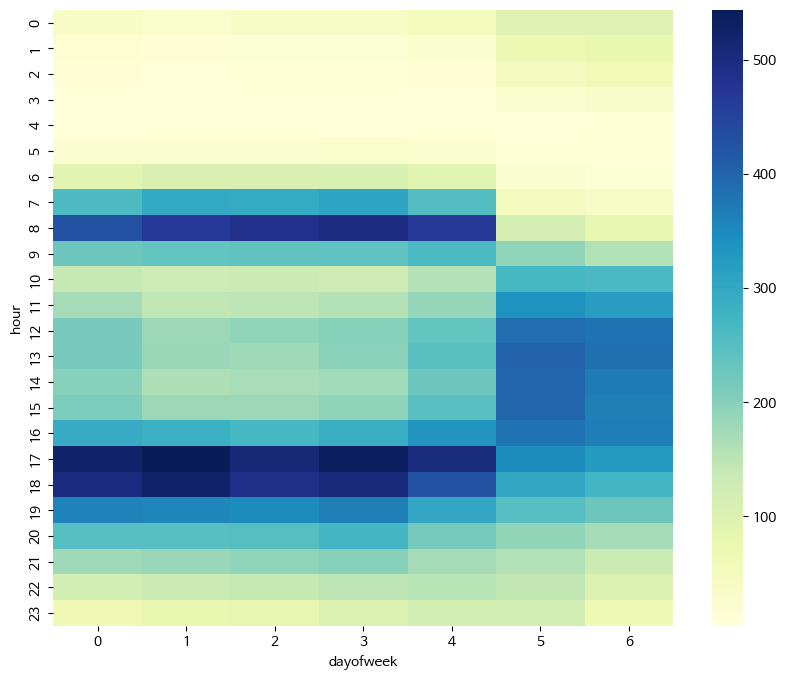

In [29]:
# 시간과 요일 평균 대여량 히트맵
pivot = train.pivot_table(index='hour', columns='dayofweek', values='count', aggfunc='mean')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=False, cmap='YlGnBu')
plt.show()

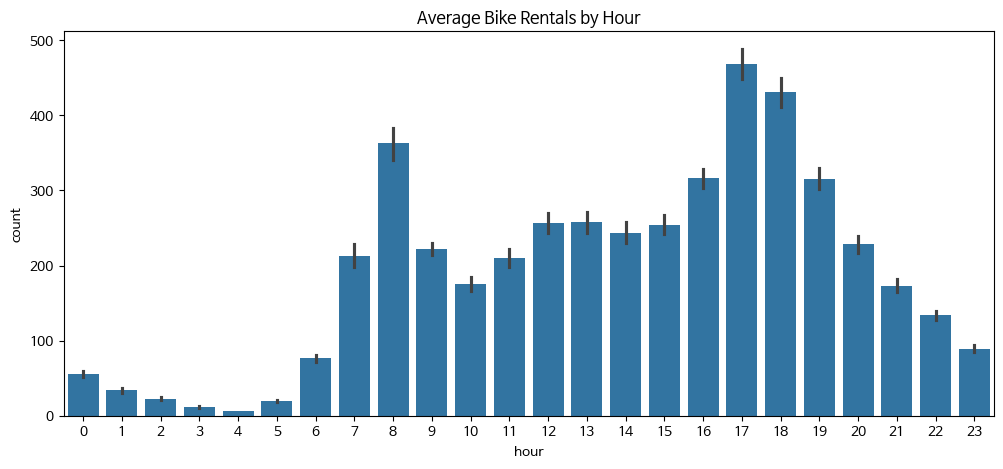

In [30]:
# 시간대별 평균 대여량 시각화
plt.figure(figsize=(12, 5))
sns.barplot(data=train, x='hour', y='count')
plt.title('Average Bike Rentals by Hour')
plt.show()

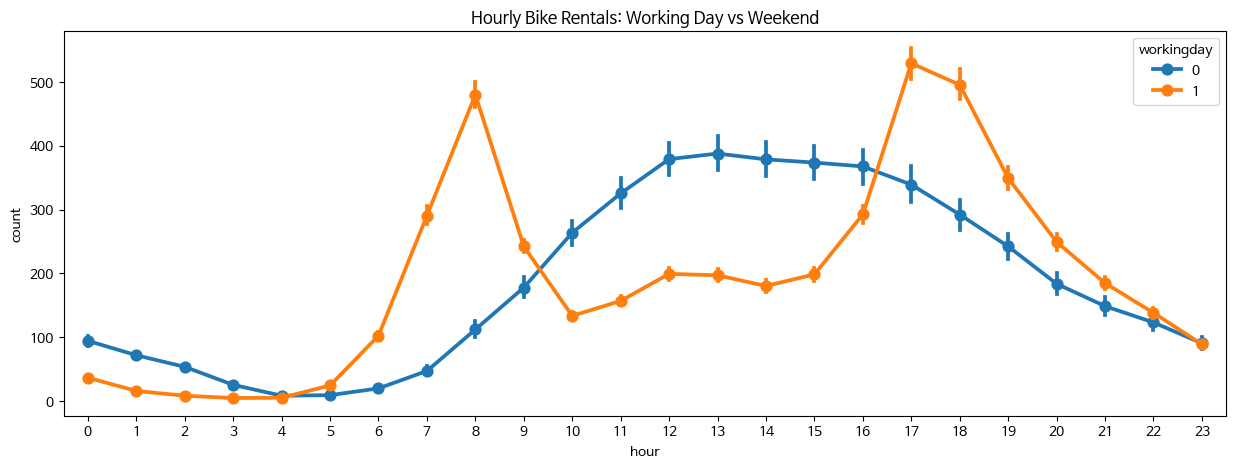

In [31]:
# 요일별(평일 1, 주말 0) 시간대별 패턴 비교
plt.figure(figsize=(15, 5))
sns.pointplot(data=train, x='hour', y='count', hue='workingday')
plt.title('Hourly Bike Rentals: Working Day vs Weekend')
plt.show()

## 계절, 온도 등 날씨 기준

In [32]:
# 날씨별 주요 기상 지표 평균 확인
weather_profile = train.groupby('weather')[['temp', 'atemp', 'humidity', 'windspeed']].mean()
weather_profile

,temp,atemp,humidity,windspeed
weather,,,,
1,20.557122,23.994126,56.716769,12.892542
2,19.614608,23.072414,69.100565,12.179905
3,19.546356,22.753091,81.341094,14.071248
4,8.200000,11.365000,86.000000,6.003200


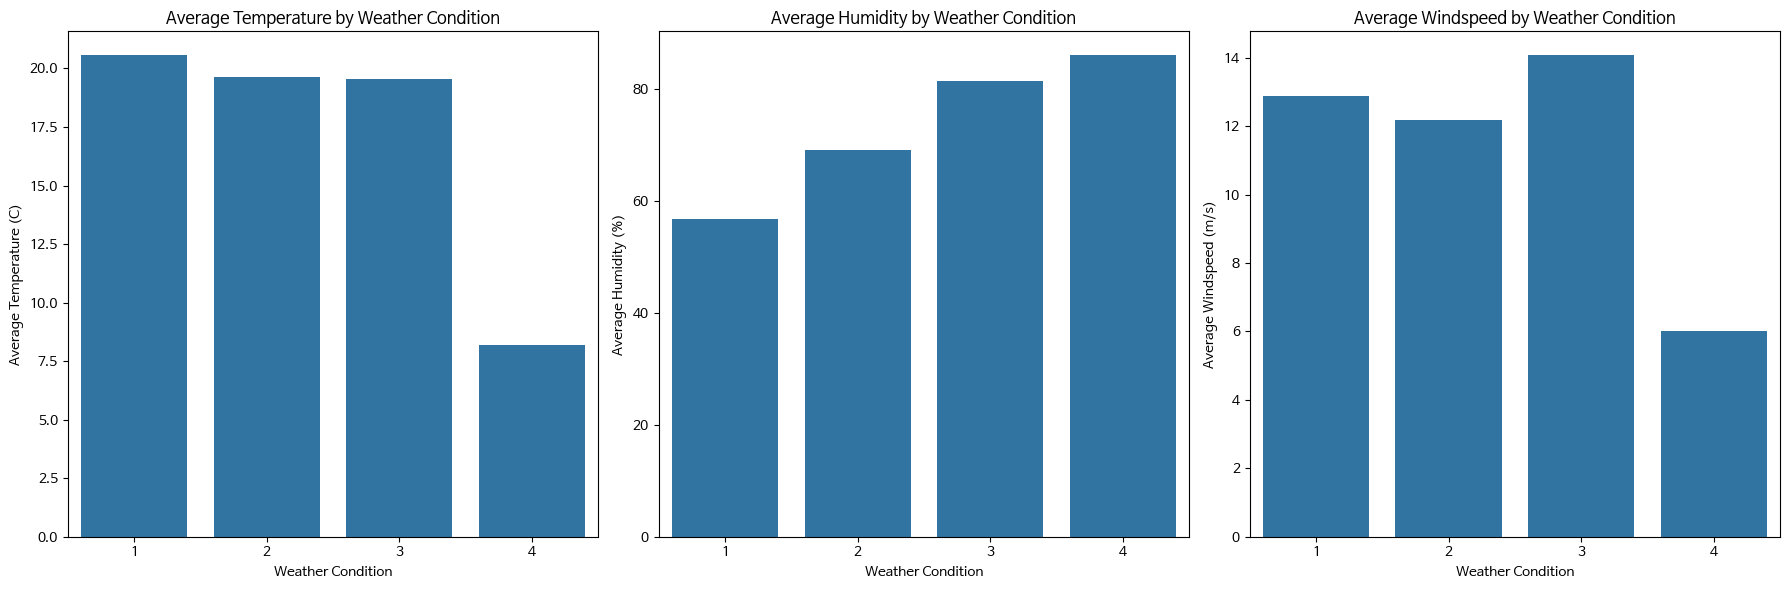

In [33]:
# 시각화
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

sns.barplot(x=weather_profile.index, y=weather_profile['temp'], ax=axes[0])
axes[0].set_title('Average Temperature by Weather Condition')
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Average Temperature (C)')

sns.barplot(x=weather_profile.index, y=weather_profile['humidity'], ax=axes[1])
axes[1].set_title('Average Humidity by Weather Condition')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Average Humidity (%)')

sns.barplot(x=weather_profile.index, y=weather_profile['windspeed'], ax=axes[2])
axes[2].set_title('Average Windspeed by Weather Condition')
axes[2].set_xlabel('Weather Condition')
axes[2].set_ylabel('Average Windspeed (m/s)')

plt.tight_layout()
plt.show()

###
*   **Weather 1 (맑음)**: 평균적으로 가장 쾌적한 온도와 낮은 습도
*   **Weather 2 (흐림, 안개)**: 습도가 다소 증가하지만, 온도와 풍속은 Weather 1과 큰 차이 없음
*   **Weather 3 (가벼운 눈/비, 천둥)**: 습도가 가장 높고, 온도는 낮아지며, 풍속은 약간 증가하는 경향
*   **Weather 4 (폭우, 우박, 폭설)**: 매우 낮은 온도와 높은 습도, 낮은 풍속

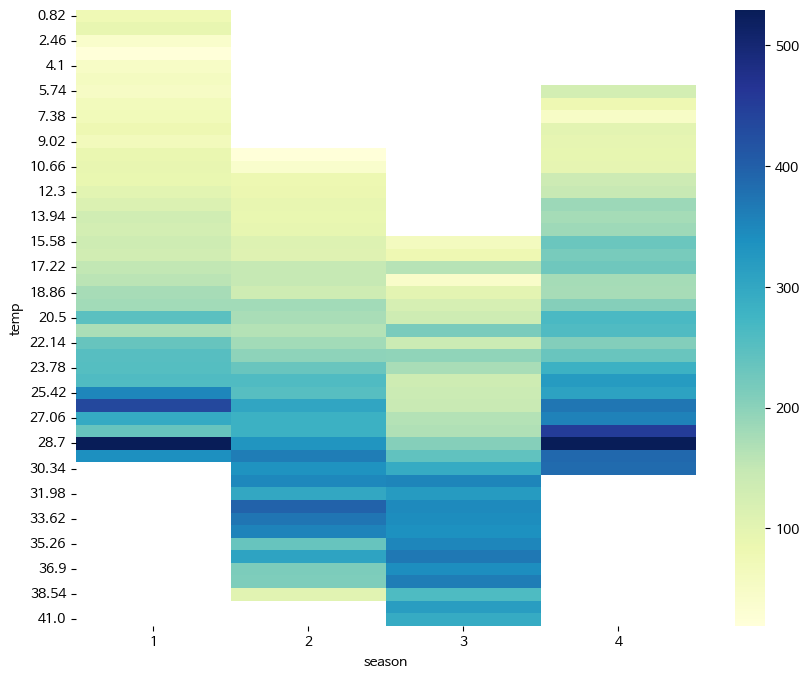

In [35]:
# 온도와 계절 조합별 평균 대여량 히트맵
pivot = train.pivot_table(index='temp', columns='season', values='count', aggfunc='mean')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=False, cmap='YlGnBu')
plt.show()

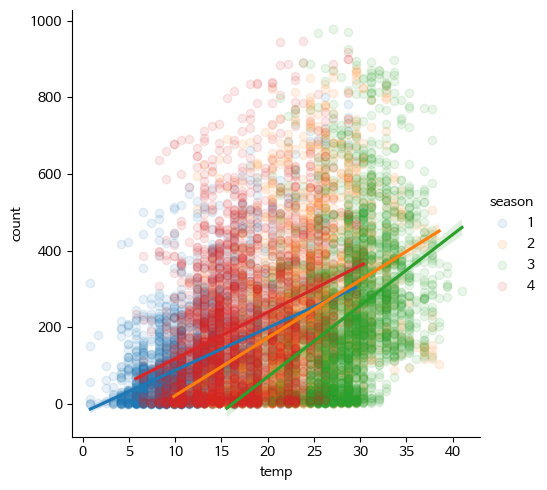

In [36]:
# 계절과 온도가 대여량에 미치는 영향
sns.lmplot(data=train, x='temp', y='count', hue='season', scatter_kws={'alpha':0.1})
plt.show()

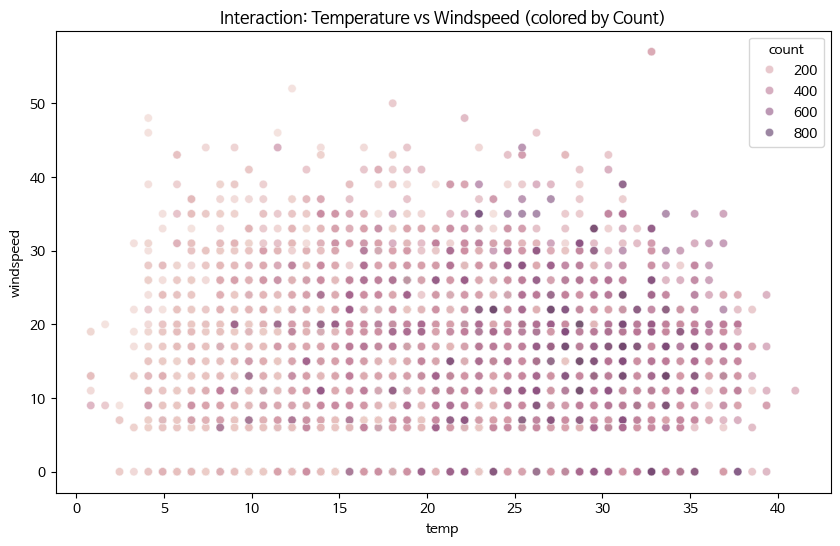

In [37]:
# 온도와 풍속의 조합별 평균 대여량 산점도
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='temp', y='windspeed', hue='count', alpha=0.6)
plt.title('Interaction: Temperature vs Windspeed (colored by Count)')
plt.show()

In [38]:
# 온도 25~35도, 풍속 30~40 이상인 데이터 포인트 필터링
high_temp_high_wind = train[
    (train['temp'] >= 25) & (train['temp'] <= 35) &
    (train['windspeed'] >= 30) & (train['windspeed'] <= 40)
]

# 결과 출력
print(f"온도 25~35도, 풍속 30~40m/s인 데이터 포인트 수: {high_temp_high_wind.shape[0]}개")
display(high_temp_high_wind.head())

# 추가로, 풍속이 40m/s를 초과하는 경우도 확인
high_temp_very_high_wind = train[
    (train['temp'] >= 25) & (train['temp'] <= 35) &
    (train['windspeed'] > 40)
]

print(f"온도 25~35도, 풍속 40m/s 초과인 데이터 포인트 수: {high_temp_very_high_wind.shape[0]}개")
display(high_temp_very_high_wind.head())

온도 25~35도, 풍속 30~40m/s인 데이터 포인트 수: 80개


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
848,2011-02-18 19:00:00,1,0,1,1,25.42,31.060,29,39.0007,16,146,162,2011,2,18,19,4
1407,2011-04-04 12:00:00,2,0,1,1,26.24,31.060,36,31.0009,59,98,157,2011,4,4,12,0
1409,2011-04-04 14:00:00,2,0,1,2,30.34,32.575,27,32.9975,47,76,123,2011,4,4,14,0
1410,2011-04-04 15:00:00,2,0,1,1,31.16,33.335,23,36.9974,47,96,143,2011,4,4,15,0
1411,2011-04-04 16:00:00,2,0,1,1,31.16,32.575,22,35.0008,59,130,189,2011,4,4,16,0


온도 25~35도, 풍속 40m/s 초과인 데이터 포인트 수: 11개


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
1412,2011-04-04 17:00:00,2,0,1,1,30.34,32.575,23,40.9973,83,283,366,2011,4,4,17,0
1839,2011-05-03 13:00:00,2,0,1,2,28.70,32.575,58,40.9973,50,144,194,2011,5,3,13,1
2755,2011-07-03 17:00:00,3,0,0,3,32.80,37.120,49,56.9969,181,177,358,2011,7,3,17,6
2756,2011-07-03 18:00:00,3,0,0,3,32.80,37.120,49,56.9969,74,107,181,2011,7,3,18,6
3307,2011-08-07 17:00:00,3,0,0,3,30.34,35.605,74,43.0006,63,131,194,2011,8,7,17,6


## temp/atemp 처리

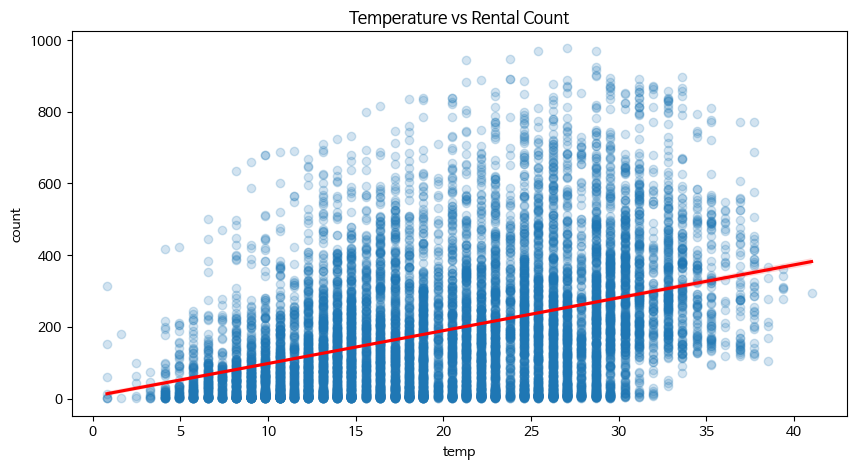

In [39]:
# 온도와 대여량의 관계 (산점도 + 회귀선)
plt.figure(figsize=(10, 5))
sns.regplot(data=train, x='temp', y='count', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Temperature vs Rental Count')
plt.show()

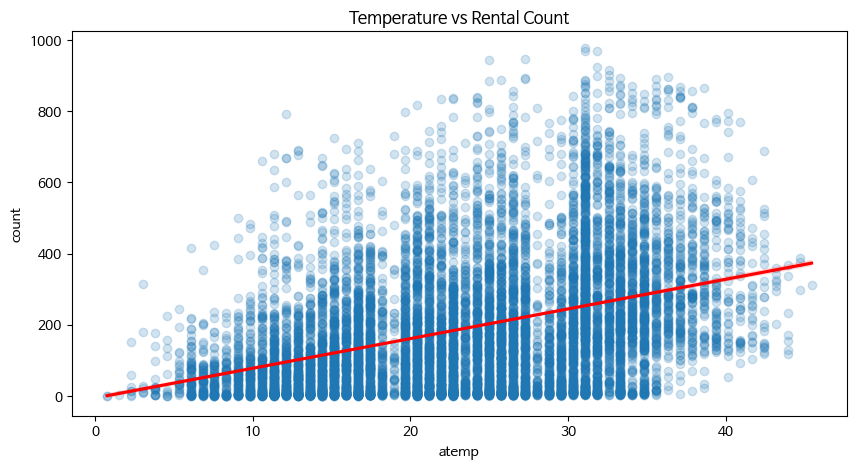

In [40]:
# 체감온도와 대여량의 관계
plt.figure(figsize=(10, 5))
sns.regplot(data=train, x='atemp', y='count', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Temperature vs Rental Count')
plt.show()

###
- 회귀선이 우상향 직선 : 기온이 올라갈 수록 대여량이 증가(너무 더운 날씨는 아니지만 어느 정도 온화한 날씨에 많이 대여)
- 35도 이상으로 더워지면 소폭 감소하는 경향
- 더운 날씨에는 대여량이 줄어든다 = 직선만으로는 확인하기 어려움 -> 다중 회귀(곡선) 검토 필요
- 선형 회귀선은 기온 상승에 따른 수요 증가를 잘 보여주지만, 폭염 구간에서의 수요 감소 패턴까지는 반영하지 못하는 한계가 있음.
- 향후 다항 회귀를 통해 이 곡선 패턴을 더 정교하게 학습시킬 필요가 있어 보임.

In [41]:
# 기온과 체감 온도의 영향은 너무 유사함
# 둘 중 뭘 살릴지 확인하기 위해 상관계수 확인
corr = train[['temp', 'atemp', 'count']].corr()
corr

,temp,atemp,count
temp,1.000000,0.984948,0.394454
atemp,0.984948,1.000000,0.389784
count,0.394454,0.389784,1.000000


In [42]:
# 상관계수가 더 낮고 중복되는 atemp 삭제
train = train.drop(['atemp'], axis=1)
train.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,81,0.0,3,13,16,2011,1,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,80,0.0,8,32,40,2011,1,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,80,0.0,5,27,32,2011,1,1,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,75,0.0,3,10,13,2011,1,1,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,75,0.0,0,1,1,2011,1,1,4,5


In [43]:
test = test.drop(['atemp'], axis=1)
test.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,year,month,day,hour,dayofweek
0,2011-01-20 00:00:00,1,0,1,1,10.66,56,26.0027,2011,1,20,0,3
1,2011-01-20 01:00:00,1,0,1,1,10.66,56,0.0000,2011,1,20,1,3
2,2011-01-20 02:00:00,1,0,1,1,10.66,56,0.0000,2011,1,20,2,3
3,2011-01-20 03:00:00,1,0,1,1,10.66,56,11.0014,2011,1,20,3,3
4,2011-01-20 04:00:00,1,0,1,1,10.66,56,11.0014,2011,1,20,4,3


In [46]:
# 년도와 계절 관계
check_table_y = pd.crosstab(train['year'], train['season'])
check_table_y

season,1,2,3,4
year,,,,
2011,1323,1367,1365,1367
2012,1363,1366,1368,1367


In [44]:
# season과 month의 관계를 표로 나타내기
check_table_s = pd.crosstab(train['season'], train['month'])
check_table_s

month,1,2,3,4,5,6,7,8,9,10,11,12
season,,,,,,,,,,,,
1,884,901,901,0,0,0,0,0,0,0,0,0
2,0,0,0,909,912,912,0,0,0,0,0,0
3,0,0,0,0,0,0,912,912,909,0,0,0
4,0,0,0,0,0,0,0,0,0,911,911,912


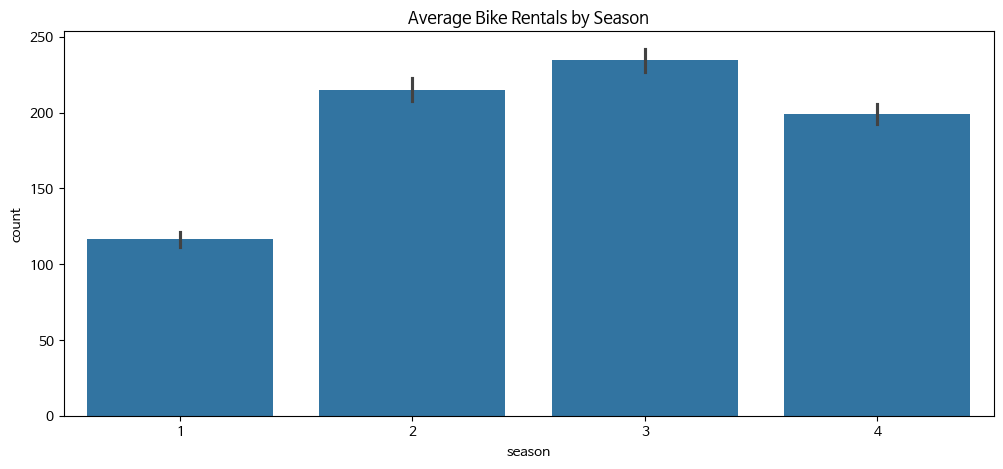

In [47]:
# season 평균 대여량 시각화
plt.figure(figsize=(12, 5))
sns.barplot(data=train, x='season', y='count')
plt.title('Average Bike Rentals by Season')
plt.show()

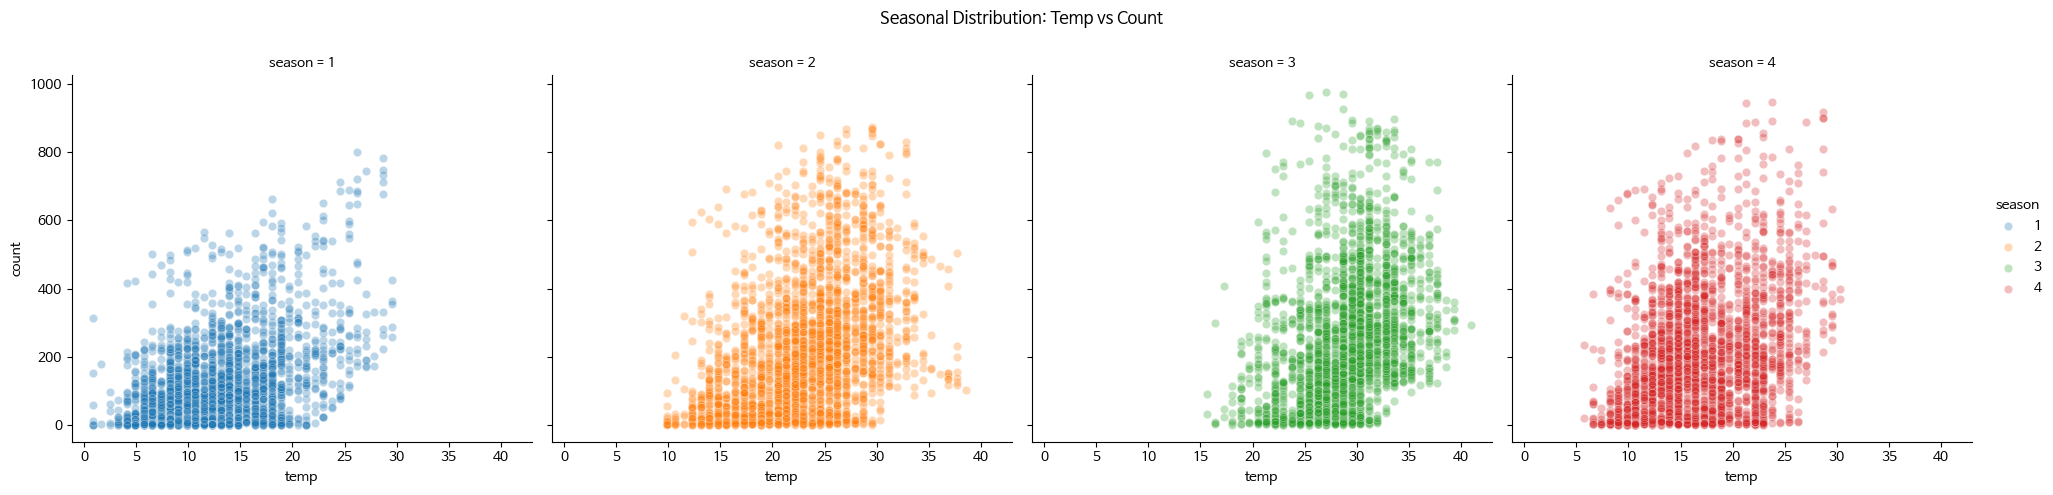

In [48]:
# season별 분포
g = sns.FacetGrid(train, col="season", hue="season", height=5)
g.map(sns.scatterplot, "temp", "count", alpha=0.3)
g.add_legend()
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Seasonal Distribution: Temp vs Count')
plt.show()

# 모델링 사전 준비

In [150]:
# 데이터 일치 재확인
ignore = {'casual', 'registered', 'count'}

# 2. 비교 후 결과만 출력 (True / False)
print((set(train.columns) - ignore) == set(test.columns))

True


In [151]:
# 머신러닝 도구 (Scikit-learn) 부르기
from sklearn.model_selection import train_test_split # 데이터 분리
from sklearn.linear_model import LinearRegression    # 선형 회귀
from sklearn.preprocessing import PolynomialFeatures # 다항 회귀 (특성 변환)
from sklearn.metrics import mean_squared_log_error, mean_squared_error   # MSLE 계산, MSE 계산

In [152]:
# 사용할 변수를 한정하고 머신러닝용 훈련/검증 데이터 분리
features_base = ['season', 'holiday', 'workingday', 'weather', 'temp',
            'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']

X_base = train[features_base]
y_base = train['count']

# 훈련 데이터와 검증 데이터 분리 (8:2 비율)
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

print(f"학습용: {X_train_base.shape}, 검증용: {X_val_base.shape}")

학습용: (8708, 11), 검증용: (2178, 11)


In [220]:
train.shape

(10886, 17)

In [221]:
test.shape

(6493, 13)

# 1차 모델링

In [153]:
model_base = LinearRegression()
model_base.fit(X_train_base, y_train_base)

LinearRegression()

In [154]:
y_predict_base = model_base.predict(X_val_base)
y_predict_base[y_predict_base < 0] = 0

In [55]:
# 모델 평가
mse = mean_squared_error(y_val_base, y_predict_base)
rmse = np.sqrt(mse)
rmsle = np.sqrt(mean_squared_log_error(y_val_base, y_predict_base))
r_square_train = model_base.score(X_train_base, y_train_base)
r_square_test = model_base.score(X_val_base, y_val_base)

print("MSE: ", mse)
print("RMSE: ", rmse)
print("RLSLE: ", rmsle)
print("R square (train): ", r_square_train)
print("R square (test): ", r_square_test)

MSE:  19780.62313189086
RMSE:  140.64360323843692
RLSLE:  1.3061817386671875
R square (train):  0.3859925174034289
R square (test):  0.39489515450673596


In [155]:
# 로그 변환 (np.log1p는 log(1+x)와 같음)
y_train_log = np.log1p(y_train_base)

# 로그 변환된 값으로 모델 학습
model_base.fit(X_train_base, y_train_log)

# 예측 수행 (결과값도 로그 형태)
preds_base_log = model_base.predict(X_val_base)

# 다시 원래 단위로 되돌리기 (지수 변환)
preds_base_exp = np.expm1(preds_base_log)

# 음수 처리 및 RMSLE 계산
preds_base_exp[preds_base_exp < 0] = 0
rmsle_new = np.sqrt(mean_squared_log_error(y_val_base, preds_base_exp))
print(f"Log Transformed RMSLE: {rmsle_new:.5f}")

Log Transformed RMSLE: 1.02501


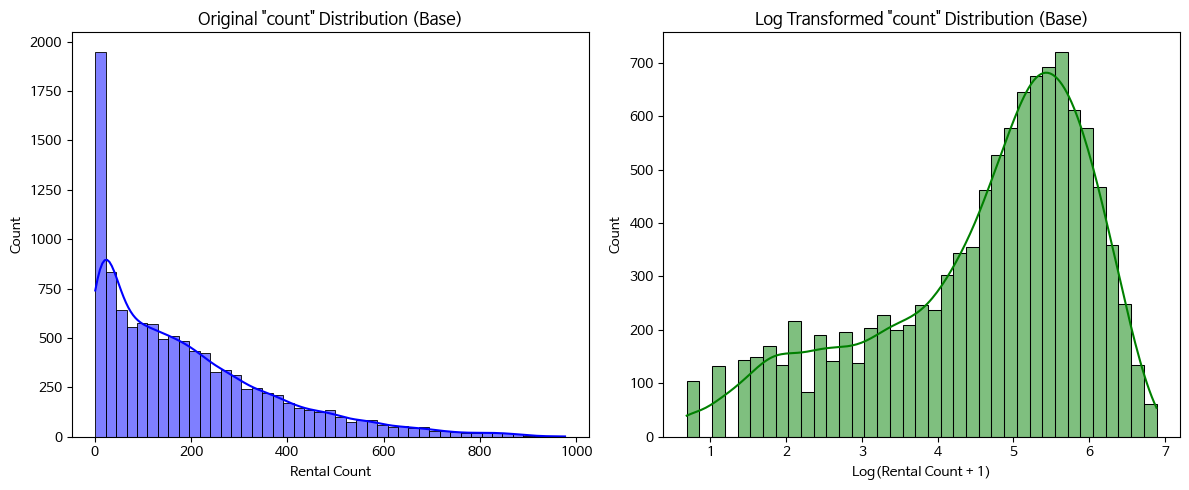

In [156]:
# 시각화 영역 설정 (1행 2열)
fig, ax = plt.subplots(figsize=(12, 5), ncols=2)

# [왼쪽] 원래 타겟값 분포 (y_base 활용)
sns.histplot(y_base, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Original "count" Distribution (Base)')
ax[0].set_xlabel('Rental Count')

# [오른쪽] 로그 변환 후 타겟값 분포
y_base_log = np.log1p(y_base)
sns.histplot(y_base_log, kde=True, ax=ax[1], color='green')
ax[1].set_title('Log Transformed "count" Distribution (Base)')
ax[1].set_xlabel('Log(Rental Count + 1)')

plt.tight_layout()
plt.show()

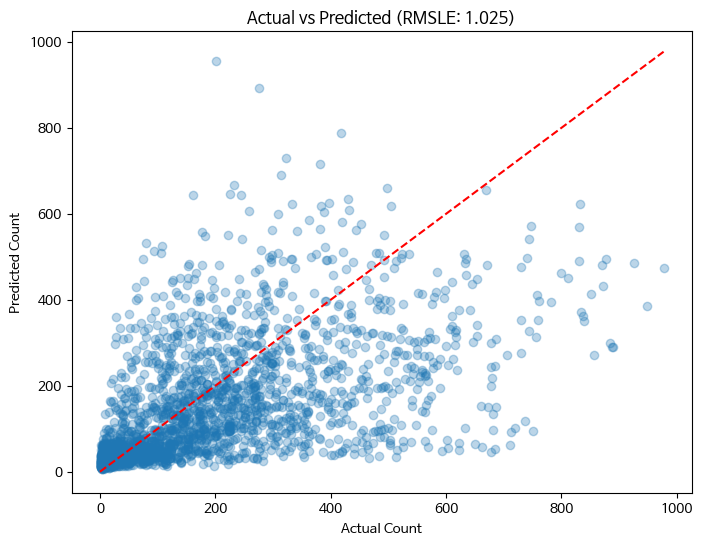

In [157]:
# 예측값과 실제값 비교 시각화
plt.figure(figsize=(8, 6))
# 실제값(y_val)과 로그 변환 후 되돌린 예측값(preds_exp) 비교
plt.scatter(y_val_base, preds_base_exp, alpha=0.3)
plt.plot([0, y_val_base.max()], [0, y_val_base.max()], 'r--') # 45도 가이드 라인
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted (RMSLE: 1.025)')
plt.show()

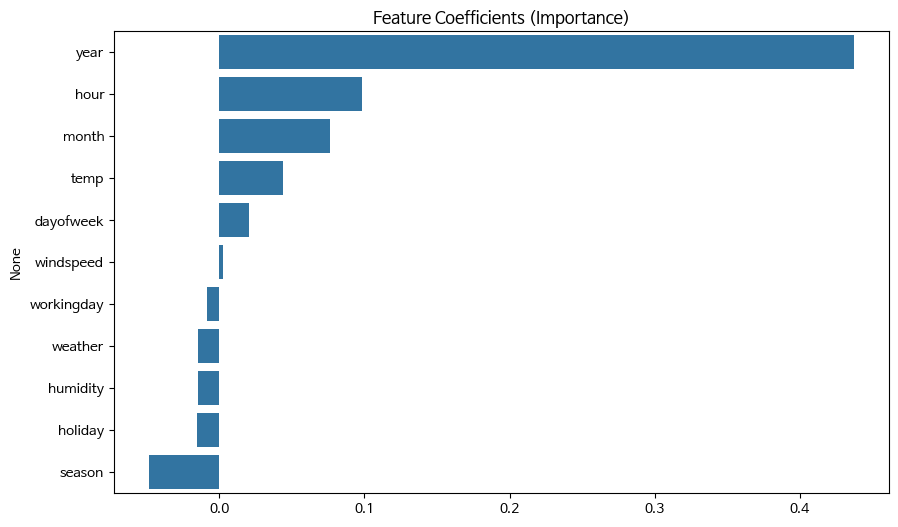

In [158]:
# 모델의 회귀 계수(coef_) 추출
coef_series = pd.Series(data=model_base.coef_, index=features_base).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=coef_series.values, y=coef_series.index)
plt.title('Feature Coefficients (Importance)')
plt.show()

# 2차 모델링
- 원핫인코딩 : 범주형 데이터를 이진 숫자로 변환

In [162]:
# 대상 컬럼 정의
cat_cols = ['season', 'weather', 'hour', 'month', 'dayofweek', 'year']

# 원-핫 인코딩 적용
train_encoded = pd.get_dummies(train, columns=cat_cols, drop_first=True)
print(f"Shape: {train.shape} -> {train_encoded.shape}")

Shape: (10886, 16) -> (10886, 57)


In [163]:
# 2차 모델링용 피처 리스트 생성
features_encoded = [col for col in train_encoded.columns if col not in ['datetime', 'count', 'casual', 'registered']]

# 새로운 X_2nd와 y 설정
X_2nd = train_encoded[features_encoded]
y_2nd = train_encoded['count'] # Keep y as raw count for now, will log transform y_train_2nd later

# 데이터 분리
X_train_2nd, X_val_2nd, y_train_2nd, y_val_2nd = train_test_split(
    X_2nd, y_2nd, test_size=0.2, random_state=42
)
print(f"학습용: {X_train_2nd.shape}, 검증용: {X_val_2nd.shape}")

학습용: (8708, 53), 검증용: (2178, 53)


In [164]:
model_base_2nd = LinearRegression()
model_base_2nd.fit(X_train_2nd, y_train_2nd)

LinearRegression()

In [165]:
y_predict_2nd = model_base_2nd.predict(X_val_2nd)
y_predict_2nd[y_predict_2nd < 0] = 0

In [166]:
# 모델 평가
mse_2 = mean_squared_error(y_val_2nd, y_predict_2nd)
rmse_2 = np.sqrt(mse_2)
rmsle_2 = np.sqrt(mean_squared_log_error(y_val_2nd, y_predict_2nd))
r_square_train_2 = model_base_2nd.score(X_train_2nd, y_train_2nd)
r_square_test_2 = model_base_2nd.score(X_val_2nd, y_predict_2nd)

print("MSE: ", mse_2)
print("RMSE: ", rmse_2)
print("RLSLE: ", rmsle_2)
print("R square (train): ", r_square_train_2)
print("R square (test): ", r_square_test_2)

MSE:  9462.244532536872
RMSE:  97.27406916818516
RLSLE:  1.09003013972223
R square (train):  0.6937635339763548
R square (test):  0.9765347986326254


In [167]:
# 로그 변환 (np.log1p는 log(1+x)와 같음)
y_train_log_2nd = np.log1p(y_train_2nd)

# 로그 변환된 값으로 모델 학습
model_base_2nd.fit(X_train_2nd, y_train_log_2nd)

# 예측 수행 (결과값도 로그 형태)
preds_base_log_2nd = model_base_2nd.predict(X_val_2nd)

# 다시 원래 단위로 되돌리기 (지수 변환)
preds_base_exp_2nd = np.expm1(preds_base_log_2nd)

# 음수 처리 및 RMSLE 계산
preds_base_exp_2nd[preds_base_exp_2nd < 0] = 0
rmsle_new_2nd = np.sqrt(mean_squared_log_error(y_val_2nd, preds_base_exp_2nd))
print(f"Log Transformed RMSLE: {rmsle_new_2nd:.5f}")

Log Transformed RMSLE: 0.58081


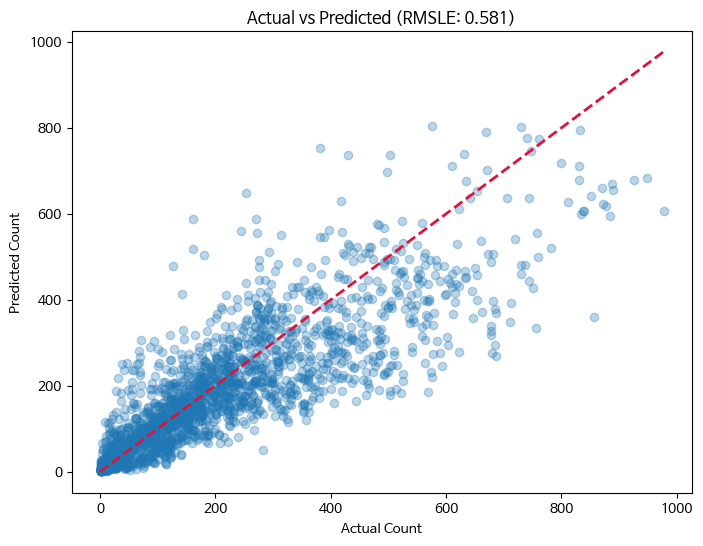

In [168]:
plt.figure(figsize=(8, 6))

# 실제값(y_val_2nd)과 되돌린 예측값(preds_base_exp_2nd) 산점도
plt.scatter(y_val_2nd, preds_base_exp_2nd, alpha=0.3)

# 45도 가이드 라인 (예측이 완벽할 경우 실제값 = 예측값)
max_val = max(y_val_2nd.max(), preds_base_exp_2nd.max())
plt.plot([0, max_val], [0, max_val], color='crimson', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title(f'Actual vs Predicted (RMSLE: {rmsle_new_2nd:.3f})')
plt.show()

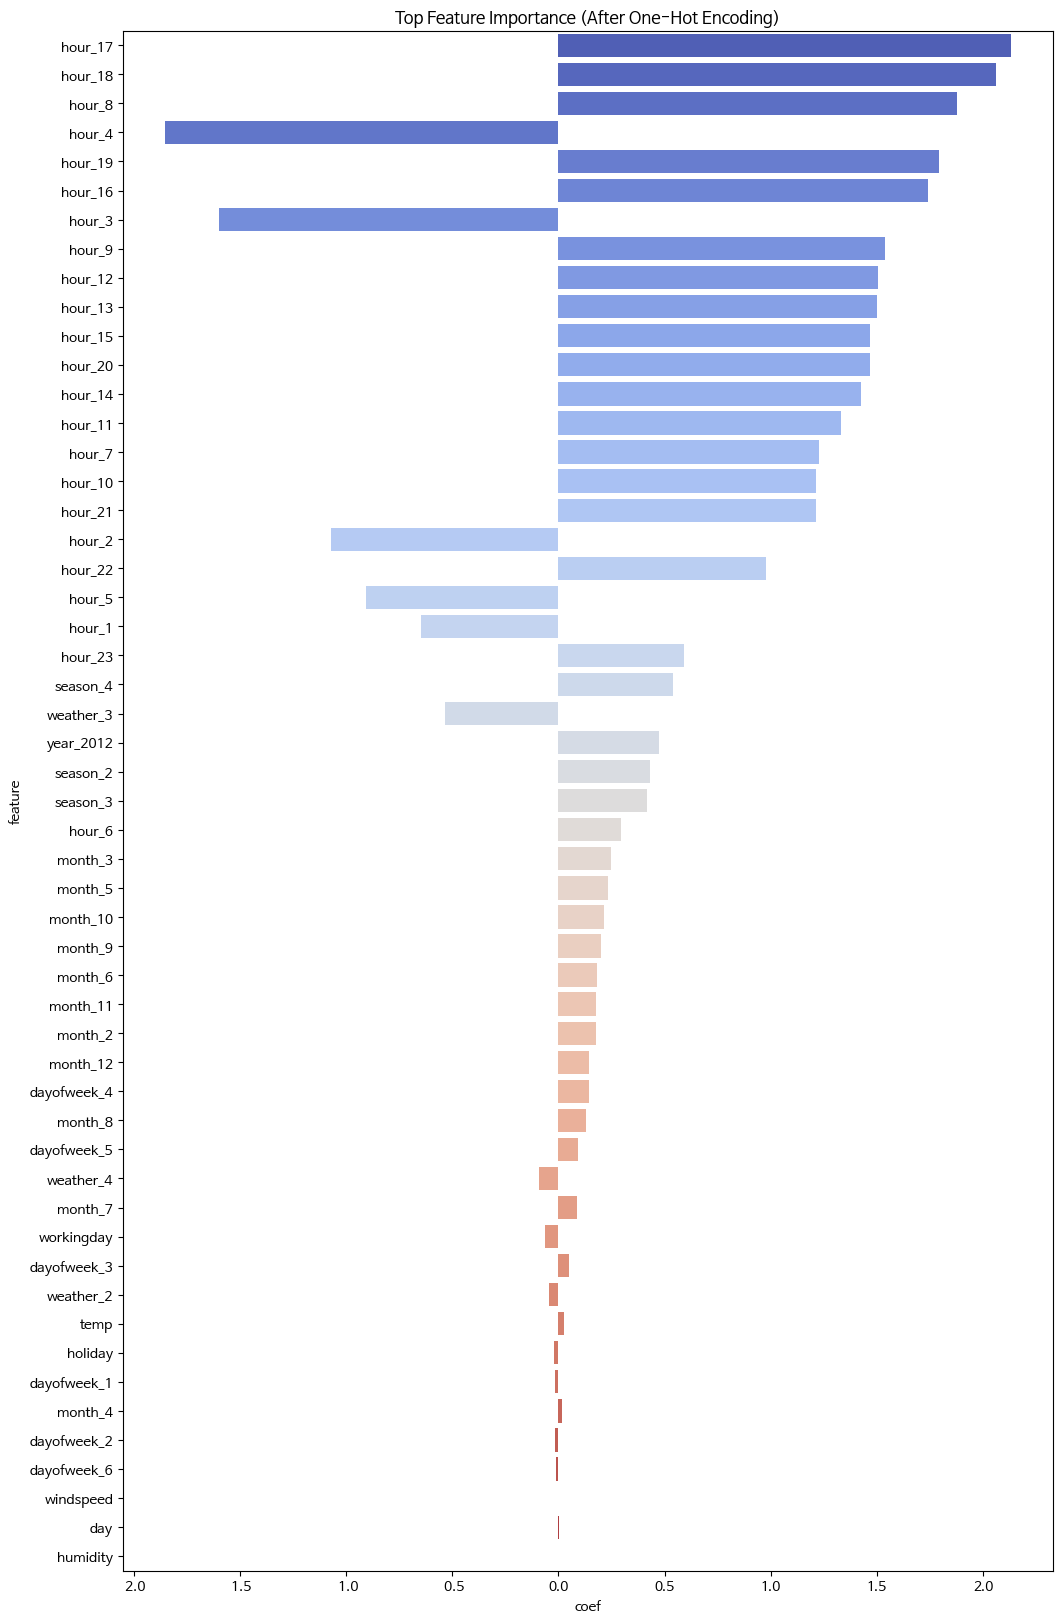

In [169]:
# 계수값과 변수명을 매칭하여 데이터프레임 만들기
coef_df = pd.DataFrame({'feature': features_encoded, 'coef': model_base_2nd.coef_})
# 절댓값 기준으로 영향력이 큰 순서대로 정렬
coef_df['abs_coef'] = coef_df['coef'].abs()
top_coefs = coef_df.sort_values(by='abs_coef', ascending=False).head(57)

# 시각화
plt.figure(figsize=(12, 20))
sns.barplot(data=top_coefs, x='coef', y='feature', palette='coolwarm')
plt.title('Top Feature Importance (After One-Hot Encoding)')
plt.show()

###
- 오후 5~6시 (hour_17, 18): 퇴근 시간대 폭발적인 수요
- 새벽 3~4시 (hour_3, 4): 대여량이 바닥을 치는 시간대
- 날씨 (weather_3, 4): 눈이나 비가 오는 상황에서 대여량 급감

# 오차 분석

In [170]:
# 인코딩된 검증 데이터 복사
error_analysis = X_val_2nd.copy()
error_analysis['actual'] = y_val_2nd
error_analysis['predict'] = preds_base_exp_2nd
error_analysis['error'] = abs(error_analysis['actual'] - error_analysis['predict'])

# 오차 큰 상위 10개
top_errors = error_analysis.sort_values(by='error', ascending=False).head(10)

# 원본 데이터에서 인덱스 기준 매칭
original_cols = ['hour', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'month', 'dayofweek']
original_info = train[original_cols].loc[top_errors.index]

# 최종 리스트 취합
error_summary = pd.concat([top_errors[['actual', 'predict', 'error']], original_info], axis=1)
error_summary

,actual,predict,error,hour,workingday,weather,temp,humidity,windspeed,year,month,dayofweek
9536,856,360.690434,495.309566,17,1,3,22.96,60,16.9979,2012,10,0
9071,162,588.591078,426.591078,8,0,2,31.16,58,16.9979,2012,9,5
8528,755,334.028863,420.971137,17,1,3,31.16,66,39.0007,2012,7,0
6726,686,268.721803,417.278197,13,0,1,24.60,60,7.0015,2012,3,5
6728,679,275.361171,403.638829,15,0,1,26.24,53,8.9981,2012,3,5
8337,253,648.405913,395.405913,18,0,1,31.98,62,7.0015,2012,7,6
6864,684,295.385636,388.614364,8,1,2,18.04,72,7.0015,2012,4,2
7798,569,185.506467,383.493533,7,1,1,19.68,77,19.9995,2012,6,1
8720,382,752.658801,370.658801,17,0,1,33.62,46,16.9979,2012,8,6
9345,977,607.255201,369.744799,18,1,1,27.06,44,16.9979,2012,9,2


In [171]:
# 과대/과소 예측 분류
error_analysis['prediction_direction'] = np.where(
    error_analysis['actual'] < error_analysis['predict'],
    'over', # 예측값이 실제값보다 크면 과대 예측
    'under' # 예측값이 실제값보다 작거나 같으면 과소 예측
)

In [172]:
# 각 방향별 예측수 및 비율 게산
prediction_counts = error_analysis['prediction_direction'].value_counts()
prediction_percentages = error_analysis['prediction_direction'].value_counts(normalize=True)

display(prediction_counts)
display(prediction_percentages)

,count
prediction_direction,
under,1134
over,1044


,proportion
prediction_direction,
under,0.520661
over,0.479339


In [173]:
# 절대 오차 기술통계 확인
error_analysis['error'].describe()

,error
count,2178.000000
mean,61.820439
std,72.543859
min,0.018791
25%,11.083063
50%,35.795089
75%,83.880697
max,495.309566


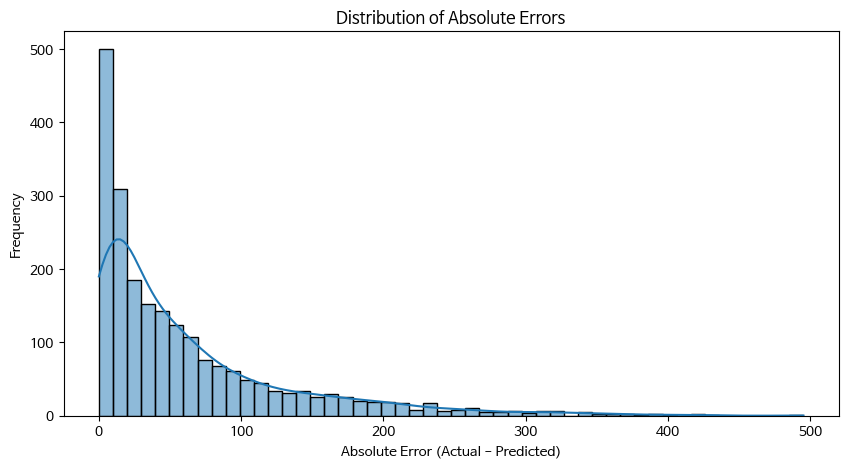

In [174]:
# 오차 분포 시각화
plt.figure(figsize=(10, 5))
sns.histplot(error_analysis['error'], bins=50, kde=True)
plt.title('Distribution of Absolute Errors')
plt.xlabel('Absolute Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

In [175]:
# 상위 5% 오차를 이상치로 정의
error_threshold = error_analysis['error'].quantile(0.95) # 상위 5% 지점의 오차 값
outlier_errors = error_analysis[error_analysis['error'] >= error_threshold]

display(len(outlier_errors))
print(f"오차 기준점 (상위 5%): {error_threshold:.2f}\n")

109

오차 기준점 (상위 5%): 213.52



In [176]:
# 원본 데이터(train)에서 인덱스 기준으로 매칭
original_cols = ['hour', 'workingday', 'weather', 'temp', 'humidity'] # 관심 있는 원본 피처

# 이상치 오차 데이터와 원본 데이터 정보를 합쳐서 출력
outlier_summary = pd.concat([train.loc[outlier_errors.index, original_cols],
                             outlier_errors[['actual', 'predict', 'error', 'prediction_direction']]], axis=1)
outlier_summary.head(10)

,hour,workingday,weather,temp,humidity,actual,predict,error,prediction_direction
10127,8,1,2,10.66,60,601,312.376711,288.623289,under
6194,8,1,2,9.84,70,513,192.153359,320.846641,under
6800,15,0,1,20.50,55,573,232.853167,340.146833,under
6840,8,1,1,13.94,57,604,294.774882,309.225118,under
9119,8,0,2,28.70,84,127,479.569474,352.569474,over
5716,8,1,1,9.84,52,419,187.275452,231.724548,under
9897,18,1,1,20.50,42,838,605.923421,232.076579,under
6874,18,1,1,27.06,41,759,500.612265,258.387735,under
9311,8,1,1,22.14,68,750,428.110568,321.889432,under
8361,18,1,1,31.16,48,872,623.476499,248.523501,under


In [177]:
# 오차가 100 이상인 데이터 필터링
high_error_data = error_analysis[error_analysis['error'] >= 100]

print(f"\n--- 오차 100 이상: {len(high_error_data)}개 ---")

# 원본 데이터(train)에서 해당 인덱스의 특징 정보 가져오기
original_cols = ['hour', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'month', 'dayofweek']
high_error_original_info = train.loc[high_error_data.index, original_cols]

# 오차 정보와 원본 특징 정보를 합치기
high_error_summary = pd.concat([high_error_original_info,
                                high_error_data[['actual', 'predict', 'error', 'prediction_direction']]], axis=1)

display(high_error_summary.head())


--- 오차 100 이상: 449개 ---


,hour,workingday,weather,temp,humidity,windspeed,year,month,dayofweek,actual,predict,error,prediction_direction
5224,18,0,1,9.84,48,12.9980,2011,12,6,163,266.682726,103.682726,over
2753,15,0,1,34.44,53,19.9995,2011,7,6,376,226.451485,149.548515,under
10127,8,1,2,10.66,60,19.0012,2012,11,2,601,312.376711,288.623289,under
8543,8,1,2,32.80,55,0.0000,2012,7,1,661,536.495397,124.504603,under
9123,12,0,2,31.16,62,19.9995,2012,9,0,543,355.001652,187.998348,under


,proportion
weather,
1,68.374165
2,25.835189
3,5.790646


Text(0.5, 1.0, 'Weather Distribution for High Error Predictions (Error >= 100)')

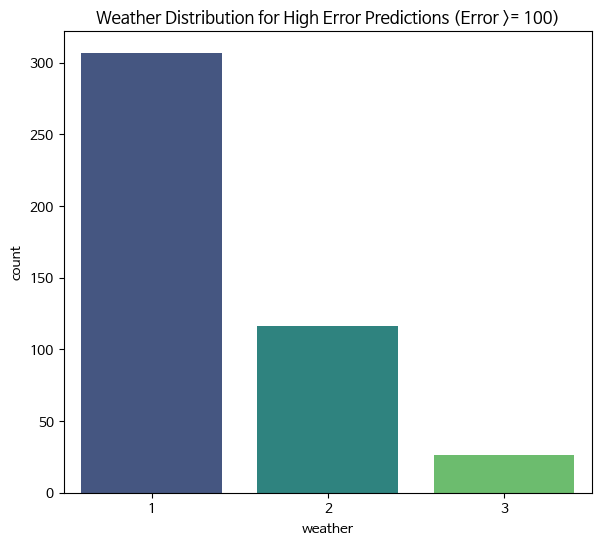

In [178]:
# 오차 100 이상인 데이터의 날씨(Weather)별 비중
display(high_error_summary['weather'].value_counts(normalize=True) * 100)

# 시각화 (시간대별 오차 분포)
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.countplot(data=high_error_summary, x='weather', palette='viridis')
plt.title('Weather Distribution for High Error Predictions (Error >= 100)')


,proportion
hour,
8,14.699332
7,13.808463
18,10.022272
17,8.685969
14,6.904232
15,6.681514
13,5.790646
12,5.790646
19,4.899777


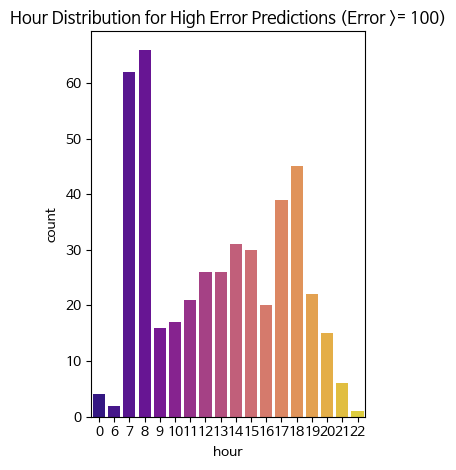

In [179]:
# 오차 100 이상인 데이터의 시간대(Hour)별 비중
display(high_error_summary['hour'].value_counts(normalize=True) * 100)

# 시각화
plt.subplot(1, 2, 2)
sns.countplot(data=high_error_summary, x='hour', palette='plasma')
plt.title('Hour Distribution for High Error Predictions (Error >= 100)')
plt.tight_layout()
plt.show()

,proportion
year,
2012,64.365256
2011,35.634744


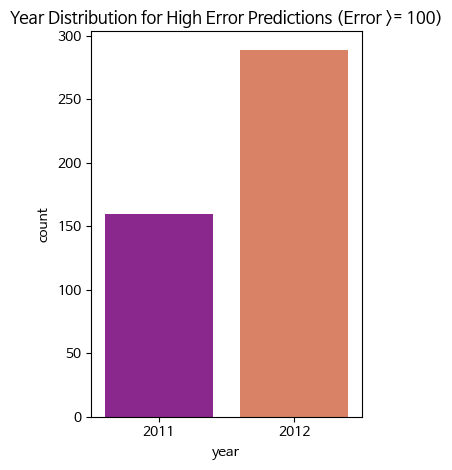

In [180]:
# 오차 100 이상인 데이터의 년도(Year)별 비중
display(high_error_summary['year'].value_counts(normalize=True) * 100)

# 시각화
plt.subplot(1, 2, 2)
sns.countplot(data=high_error_summary, x='year', palette='plasma')
plt.title('Year Distribution for High Error Predictions (Error >= 100)')
plt.tight_layout()
plt.show()

# 조합 변수 적용
- is_rush_hour
- rush_weather
- temp_band

In [215]:
# 조합 변수 생성 함수 정의
def create_combined_features(df):
    df['is_rush_hour'] = df['hour'].isin([7,8,9,17,18,19]).astype(int)
    df['rush_weather'] = df['is_rush_hour'].astype(str) + "_" + train['weather'].astype(str)
    return df

# train 데이터에 조합 변수 적용
train_combi = create_combined_features(train.copy())

# test 데이터에 조합 변수 적용
test_combi = create_combined_features(test.copy())

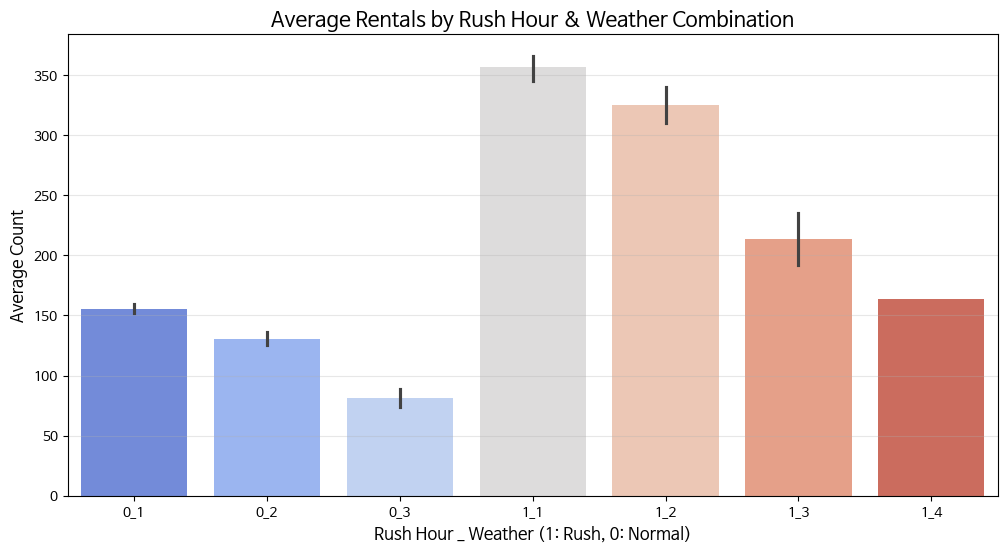

In [217]:
# 출퇴근 + 날씨 시각화
plt.figure(figsize=(12, 6))
order = sorted(train_combi['rush_weather'].unique()) # 조합 순서 정렬 (0_1, 0_2... 1_1...)
sns.barplot(data=train_combi, x='rush_weather', y='count', palette='coolwarm', order=order)

plt.title('Average Rentals by Rush Hour & Weather Combination', fontsize=15)
plt.xlabel('Rush Hour _ Weather (1: Rush, 0: Normal)', fontsize=12)
plt.ylabel('Average Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

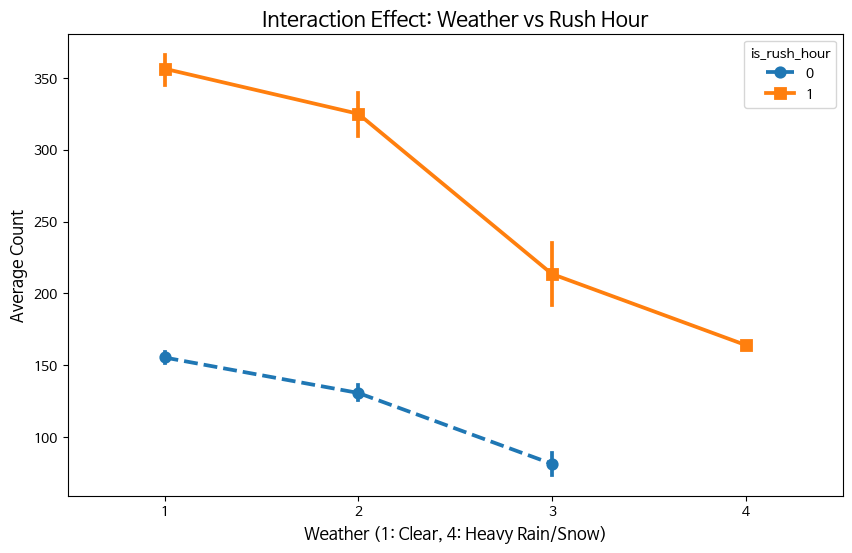

In [218]:
# 출퇴근 + 날씨 영향력 시각화
plt.figure(figsize=(10, 6))
sns.pointplot(data=train_combi, x='weather', y='count', hue='is_rush_hour',
              markers=["o", "s"], linestyles=["--", "-"])

plt.title('Interaction Effect: Weather vs Rush Hour', fontsize=15)
plt.xlabel('Weather (1: Clear, 4: Heavy Rain/Snow)', fontsize=12)
plt.ylabel('Average Count', fontsize=12)
plt.show()

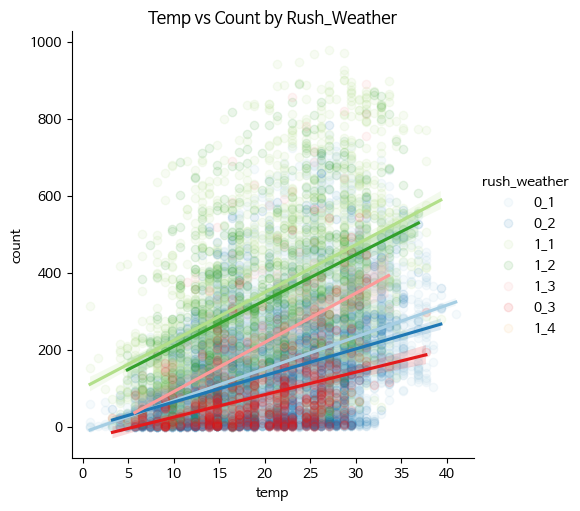

In [184]:
# rush_weather 조합별로 온도가 대여량에 미치는 영향 확인
sns.lmplot(data=train_combi, x='temp', y='count', hue='rush_weather', scatter_kws={'alpha':0.1}, palette='Paired')
plt.title('Temp vs Count by Rush_Weather')
plt.show()

In [190]:
# 온도 구간 세분화
"""
veryvery cold : -10~-5
very cold : -6~0
cold : 1~5
mild : 6~10
warm : 11~15
very warm : 15~20
veryvery warm : 21~25
hot : 26~30
very hot : 31~35
veryvery hot : 36~40
extreme hot : over 41~
"""
bins = [-np.inf, -11, -6, 0, 5, 10, 15, 20, 25, 30, 35, 40, np.inf]
labels = [
    'extreme cold', 'veryvery cold', 'very cold', 'cold', 'mild', 'warm',
    'very warm', 'veryvery warm', 'hot', 'very hot', 'veryvery hot', 'extreme hot'
]

# 새로운 temp_band 생성
train_combi['temp_band'] = pd.cut(train_combi['temp'], bins=bins, labels=labels)
train_combi[['temp', 'temp_band']].head()

,temp,temp_band
0,9.84,mild
1,9.02,mild
2,9.02,mild
3,9.84,mild
4,9.84,mild


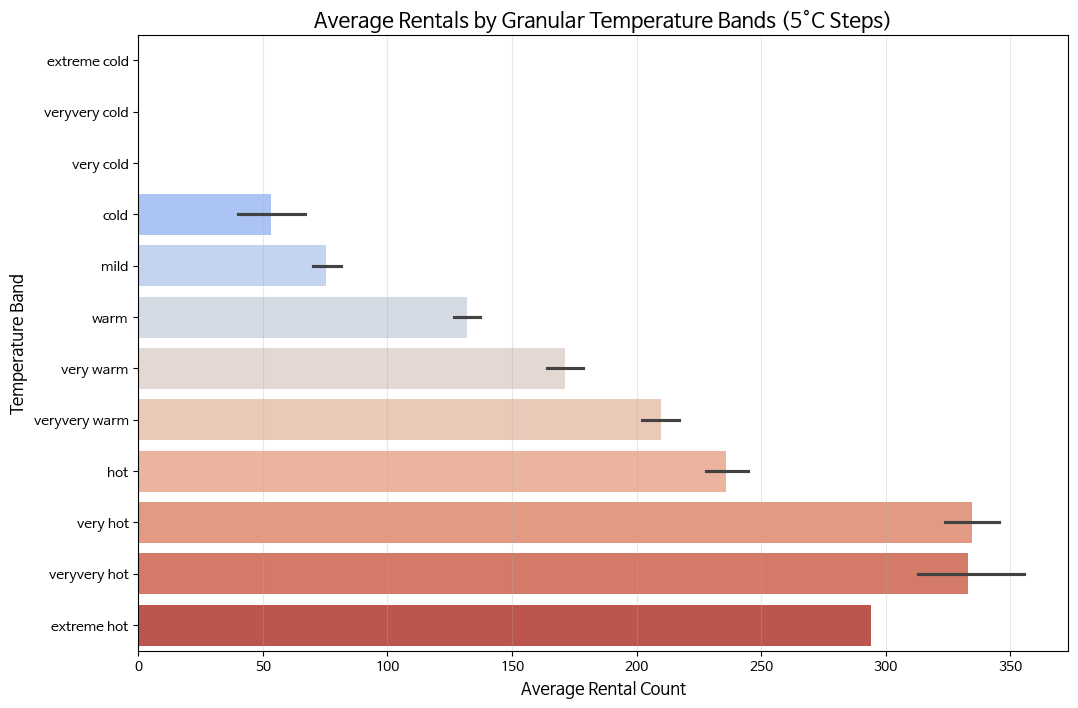

In [191]:
# 온도 구간별 평균 대여량 시각화
plt.figure(figsize=(12, 8))
sns.barplot(data=train_combi, x='count', y='temp_band', palette='coolwarm', order=labels)

plt.title('Average Rentals by Granular Temperature Bands (5°C Steps)', fontsize=15)
plt.xlabel('Average Rental Count', fontsize=12)
plt.ylabel('Temperature Band', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

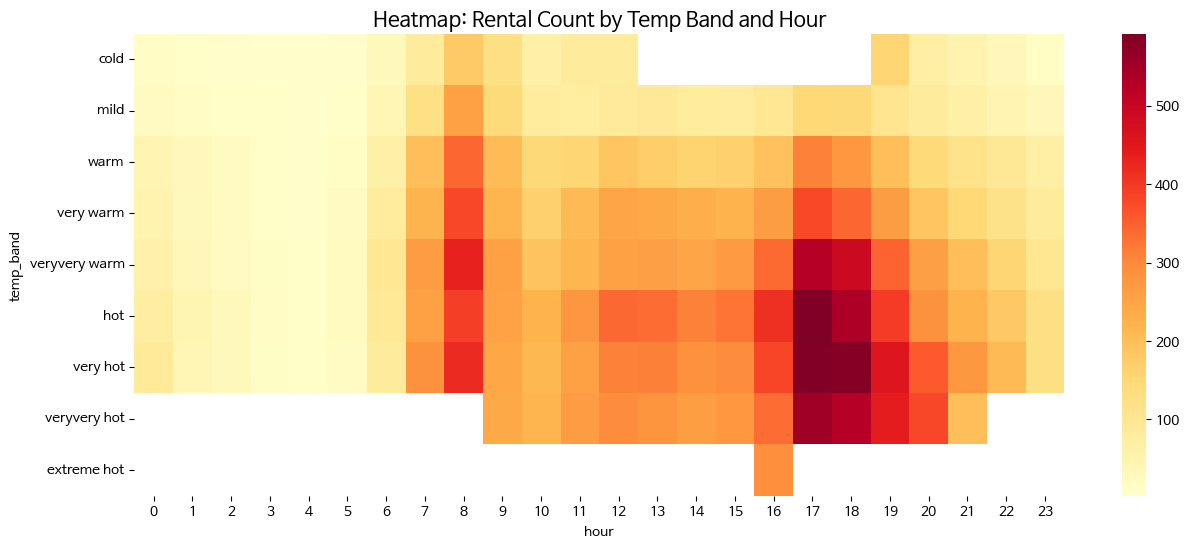

In [192]:
# 온도 구간과 시간대별 평균 대여량
temp_hour_pivot = train_combi.pivot_table(index='temp_band', columns='hour', values='count', aggfunc='mean')

# 히트맵 그리기
plt.figure(figsize=(15, 6))
sns.heatmap(temp_hour_pivot, annot=False, cmap='YlOrRd')
plt.title('Heatmap: Rental Count by Temp Band and Hour', fontsize=15)
plt.show()

In [193]:
# 각 온도 구간별 데이터 개수(빈도) 확인
train_combi['temp_band'].value_counts().sort_index()

,count
temp_band,
extreme cold,0
veryvery cold,0
very cold,0
cold,129
mild,1130
warm,2134
very warm,1915
veryvery warm,2080
hot,2254


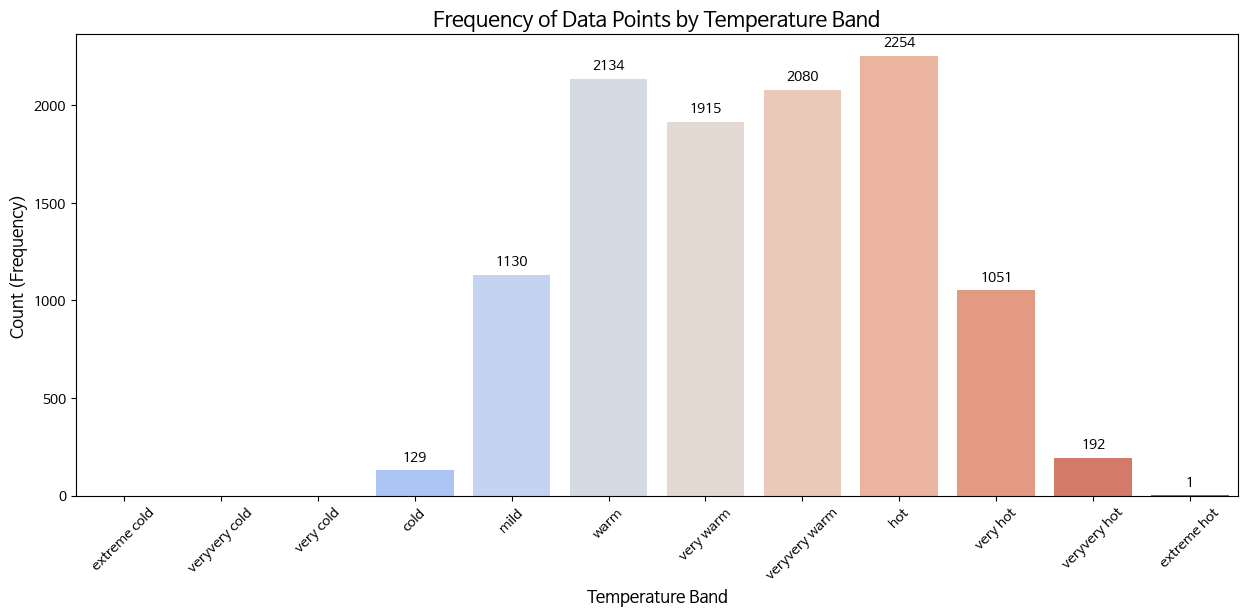

In [194]:
# sns.countplot 그리기
plt.figure(figsize=(15, 6))
sns.countplot(data=train_combi, x='temp_band', palette='coolwarm', order=labels)

# 그래프 제목 및 라벨링
plt.title('Frequency of Data Points by Temperature Band', fontsize=15)
plt.xlabel('Temperature Band', fontsize=12)
plt.ylabel('Count (Frequency)', fontsize=12)

# 각 막대 위에 실제 숫자 표시하기
ax = plt.gca() # 현재 활성화된 축 가져오기
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9),
                textcoords = 'offset points', fontsize=10)

plt.xticks(rotation=45) # 글자가 겹치면 대각선으로 회전
plt.show()

In [195]:
train_combi['temp_band'].dtype

CategoricalDtype(categories=['extreme cold', 'veryvery cold', 'very cold', 'cold', 'mild',
                  'warm', 'very warm', 'veryvery warm', 'hot', 'very hot',
                  'veryvery hot', 'extreme hot'],
, ordered=True, categories_dtype=object)

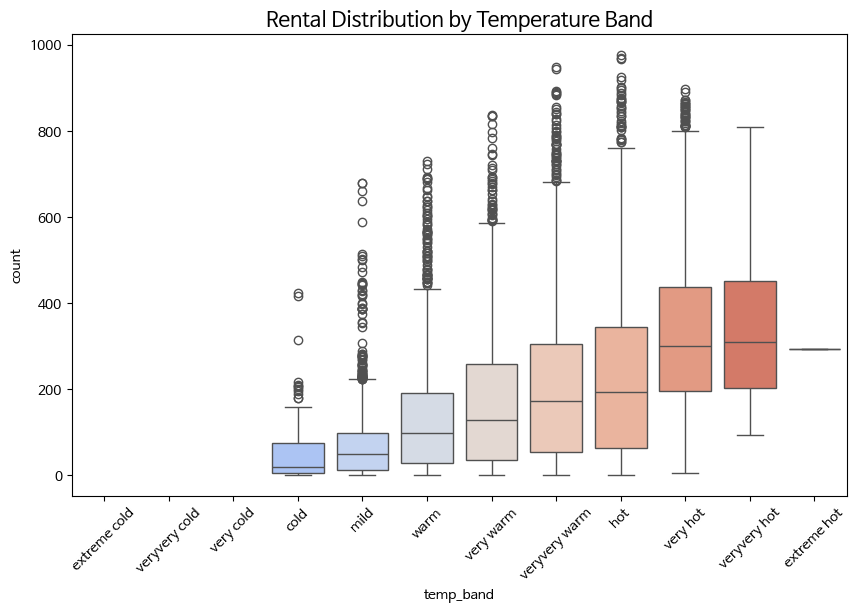

In [197]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_combi, x='temp_band', y='count', palette='coolwarm', order=labels)
plt.title('Rental Distribution by Temperature Band', fontsize=15)
plt.xticks(rotation=45) # 글자가 겹치면 대각선으로 회전
plt.show()

In [198]:
train_combi.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek,is_rush_hour,rush_weather,temp_band
0,2011-01-01 00:00:00,1,0,0,1,9.84,81,0.0,3,13,16,2011,1,1,0,5,0,0_1,mild
1,2011-01-01 01:00:00,1,0,0,1,9.02,80,0.0,8,32,40,2011,1,1,1,5,0,0_1,mild
2,2011-01-01 02:00:00,1,0,0,1,9.02,80,0.0,5,27,32,2011,1,1,2,5,0,0_1,mild
3,2011-01-01 03:00:00,1,0,0,1,9.84,75,0.0,3,10,13,2011,1,1,3,5,0,0_1,mild
4,2011-01-01 04:00:00,1,0,0,1,9.84,75,0.0,0,1,1,2011,1,1,4,5,0,0_1,mild


# 이상치 vs. 일반
